In [1]:
#====================================
# Customer Churn Prediction Report
# Step 1: Import Required Libraries
#====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Display all columns
pd.set_option('display.max_columns', None)

print('Libraries Imported Successfully')

Libraries Imported Successfully


In [2]:
from google.colab import files

uploaded = files.upload()

Saving Telco_Customer_Churn_Dataset  (3).csv to Telco_Customer_Churn_Dataset  (3).csv


In [3]:
df = pd.read_csv("Telco_Customer_Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (7043, 21)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.dropna(inplace=True)

print(df.shape)

(7032, 21)


In [11]:
df.drop("customerID", axis=1, inplace=True)

print(df.shape)

(7032, 20)


In [12]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

df["Churn"].value_counts()

,count
Churn,
0,5163
1,1869


In [13]:
categorical_columns = df.select_dtypes(include=["object"]).columns

print(categorical_columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [14]:
df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

In [15]:
print(df.shape)

(7032, 31)


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7032 non-null   int64  
 5   gender_Male                            7032 non-null   bool   
 6   Partner_Yes                            7032 non-null   bool   
 7   Dependents_Yes                         7032 non-null   bool   
 8   PhoneService_Yes                       7032 non-null   bool   
 9   MultipleLines_No phone service         7032 non-null   bool   
 10  MultipleLines_Yes                      7032 non-null   bool   
 11  InternetS

In [17]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print(X.shape)
print(y.shape)

(7032, 30)
(7032,)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [19]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (5625, 30)
Testing Features  : (1407, 30)
Training Labels   : (5625,)
Testing Labels    : (1407,)


# PART 2 [EDA]

In [20]:
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

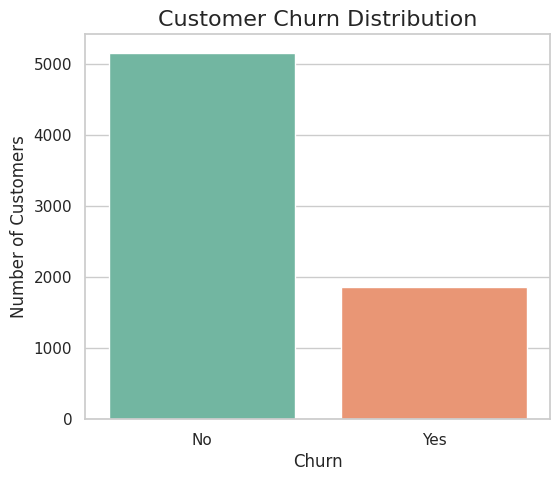

In [21]:
plt.figure(figsize=(6,5))

sns.countplot(x="Churn", data=df, palette="Set2")

plt.title("Customer Churn Distribution", fontsize=16)
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.xticks([0,1],["No","Yes"])

plt.show()

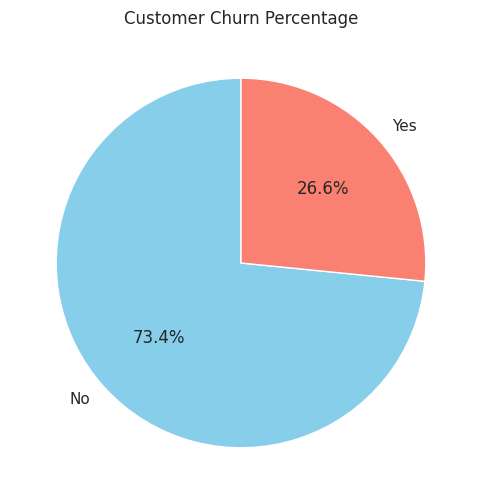

In [22]:
plt.figure(figsize=(6,6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["No","Yes"],
    startangle=90,
    colors=["skyblue","salmon"]
)

plt.title("Customer Churn Percentage")
plt.ylabel("")

plt.show()

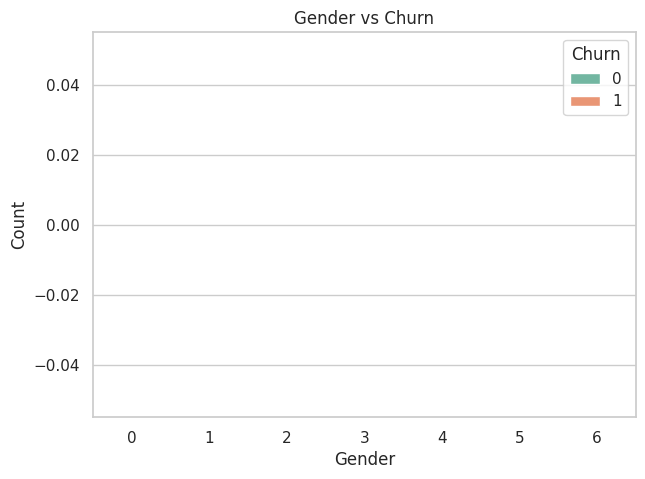

In [23]:
gender = df["gender_Male"].map({1:"Male",0:"Female"})

plt.figure(figsize=(7,5))

sns.countplot(x=gender, hue=df["Churn"], palette="Set2")

plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

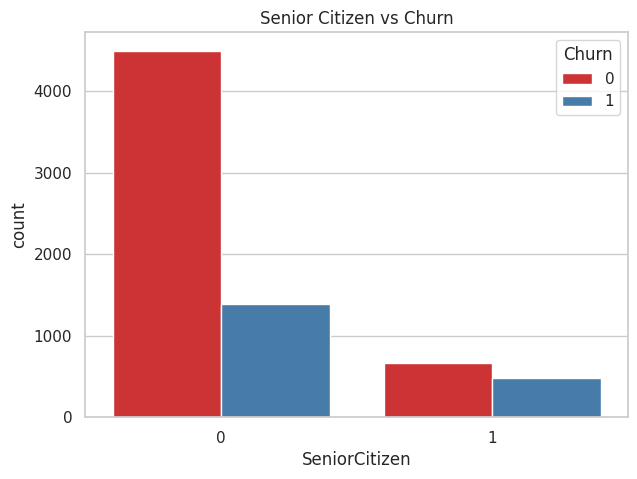

In [24]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="SeniorCitizen",
    hue="Churn",
    data=df,
    palette="Set1"
)

plt.title("Senior Citizen vs Churn")

plt.show()

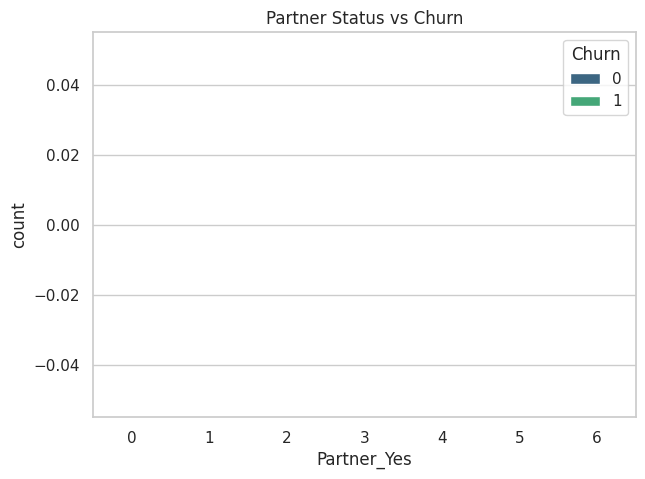

In [25]:
partner = df["Partner_Yes"].map({1:"Yes",0:"No"})

plt.figure(figsize=(7,5))

sns.countplot(
    x=partner,
    hue=df["Churn"],
    palette="viridis"
)

plt.title("Partner Status vs Churn")

plt.show()

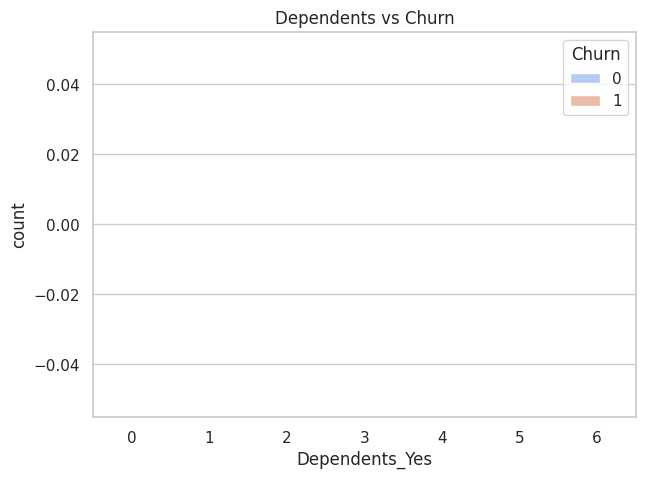

In [26]:
dependents = df["Dependents_Yes"].map({1:"Yes",0:"No"})

plt.figure(figsize=(7,5))

sns.countplot(
    x=dependents,
    hue=df["Churn"],
    palette="coolwarm"
)

plt.title("Dependents vs Churn")

plt.show()

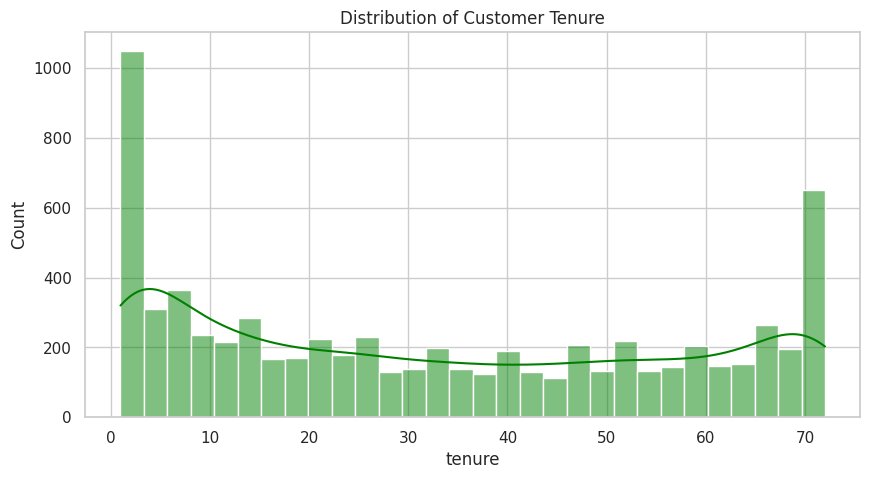

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["tenure"],
    bins=30,
    kde=True,
    color="green"
)

plt.title("Distribution of Customer Tenure")

plt.show()

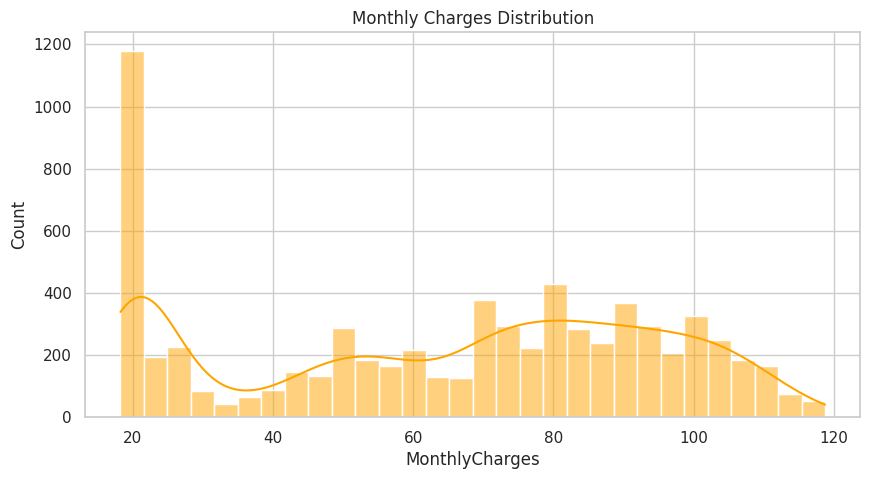

In [28]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["MonthlyCharges"],
    bins=30,
    kde=True,
    color="orange"
)

plt.title("Monthly Charges Distribution")

plt.show()

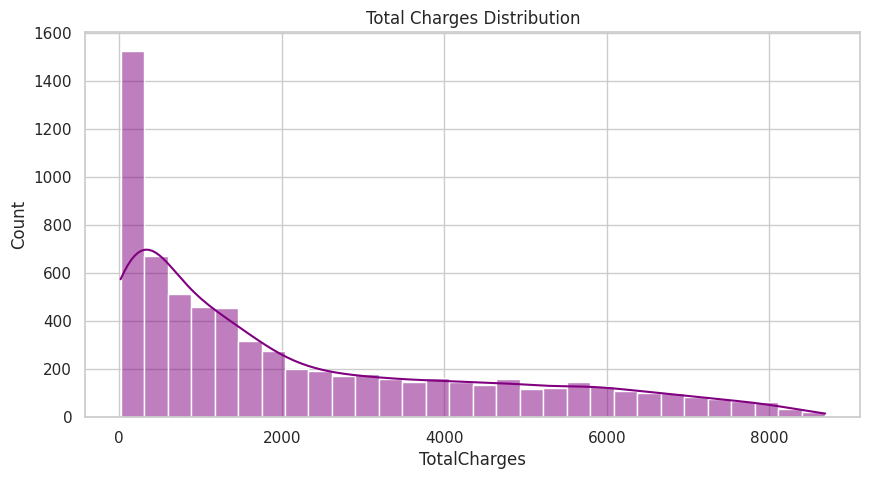

In [29]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["TotalCharges"],
    bins=30,
    kde=True,
    color="purple"
)

plt.title("Total Charges Distribution")

plt.show()

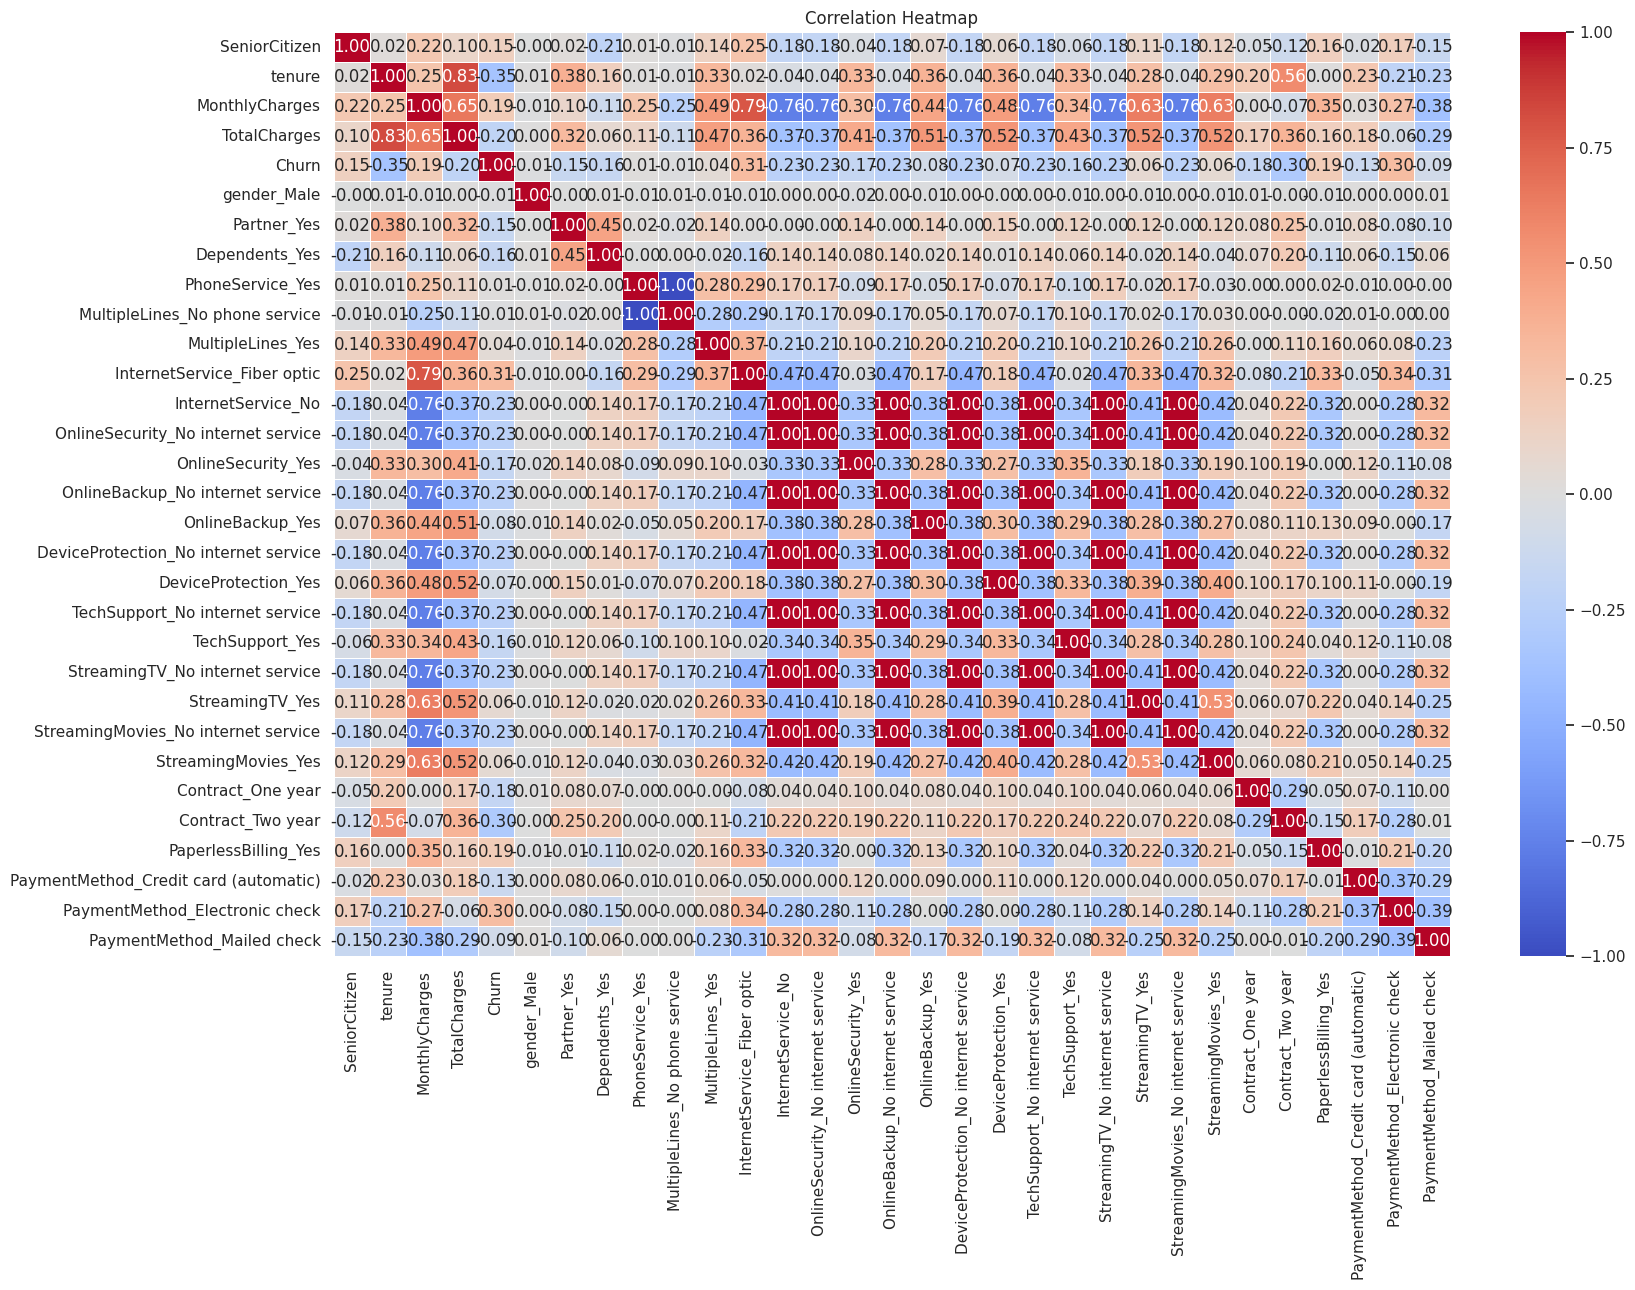

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,12))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    linewidths=0.5,
    annot=True, # Add annotations
    fmt=".2f" # Format annotations to two decimal places
)

plt.title("Correlation Heatmap")

plt.show()

In [31]:
correlation = df.corr()["Churn"].sort_values(ascending=False)

print(correlation.head(15))

Churn                             1.000000
InternetService_Fiber optic       0.307463
PaymentMethod_Electronic check    0.301455
MonthlyCharges                    0.192858
PaperlessBilling_Yes              0.191454
SeniorCitizen                     0.150541
StreamingTV_Yes                   0.063254
StreamingMovies_Yes               0.060860
MultipleLines_Yes                 0.040033
PhoneService_Yes                  0.011691
gender_Male                      -0.008545
MultipleLines_No phone service   -0.011691
DeviceProtection_Yes             -0.066193
OnlineBackup_Yes                 -0.082307
PaymentMethod_Mailed check       -0.090773
Name: Churn, dtype: float64


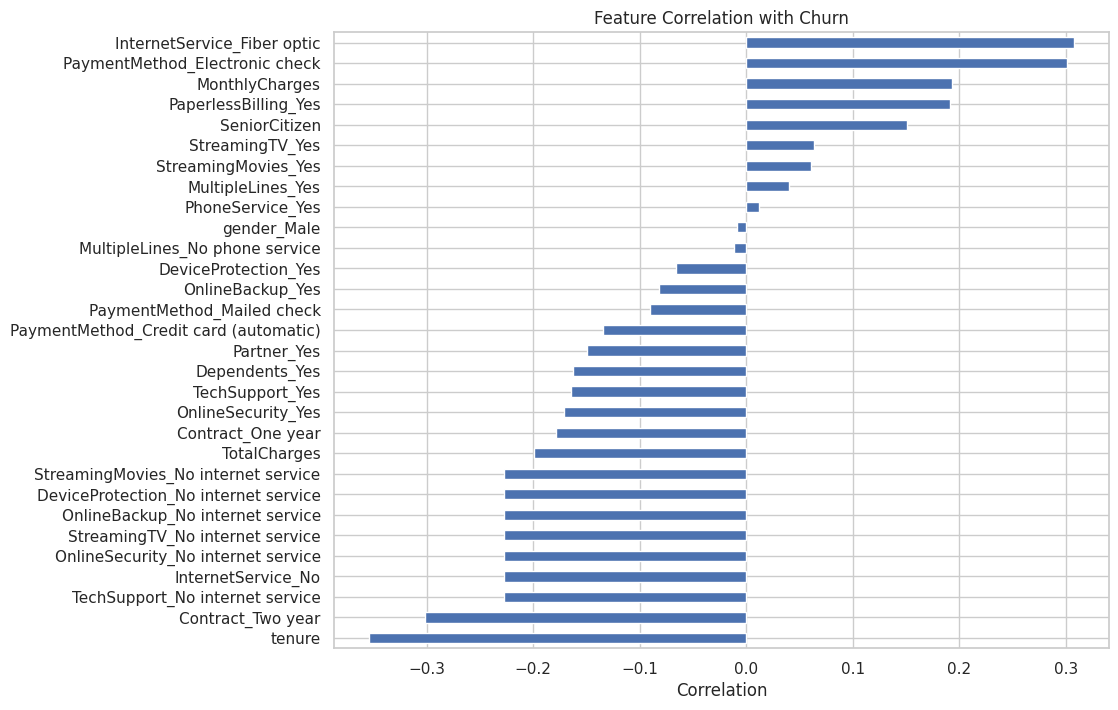

In [32]:
plt.figure(figsize=(10,8))

correlation.drop("Churn").sort_values().plot(kind="barh")

plt.title("Feature Correlation with Churn")

plt.xlabel("Correlation")

plt.show()

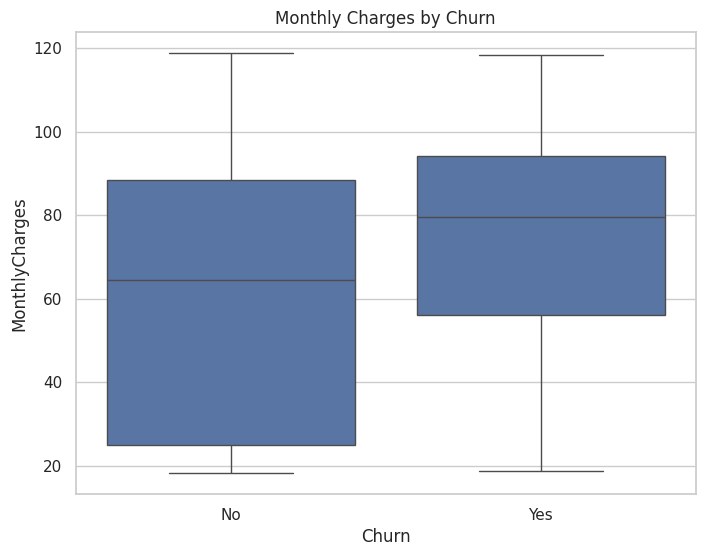

In [33]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.xticks([0,1],["No","Yes"])

plt.title("Monthly Charges by Churn")

plt.show()

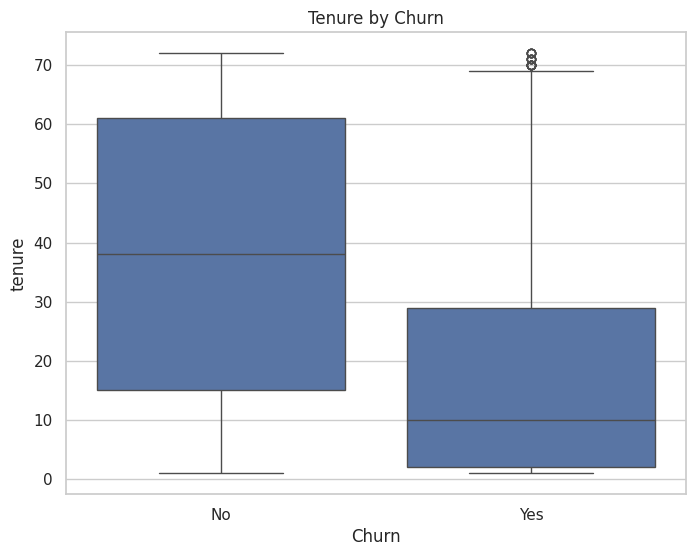

In [34]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.xticks([0,1],["No","Yes"])

plt.title("Tenure by Churn")

plt.show()

# PART 3 [MACHINE LEARNING MODEL BUILDING]

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [36]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))

Accuracy: 0.8031272210376688


In [37]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



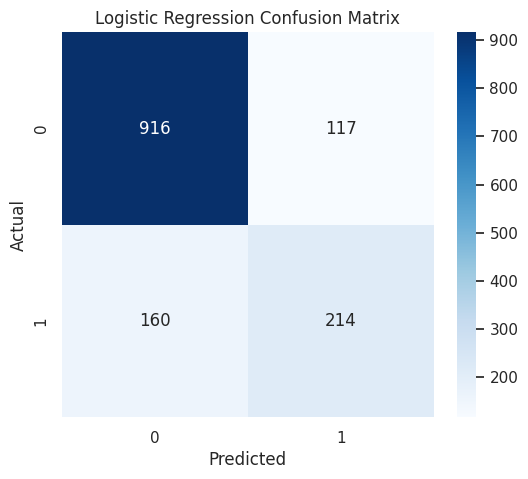

In [38]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, lr_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [39]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))

Accuracy: 0.7185501066098081


In [40]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.7867803837953091


In [41]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, knn_pred))

Accuracy: 0.746268656716418


In [42]:
svm = SVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, svm_pred))

Accuracy: 0.7341862117981521


In [43]:
nb = GaussianNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, nb_pred))

Accuracy: 0.6439232409381663


In [44]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Support Vector Machine",
        "Naive Bayes"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, nb_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.803127
1,Decision Tree,0.718550
2,Random Forest,0.786780
3,KNN,0.746269
4,Support Vector Machine,0.734186
5,Naive Bayes,0.643923


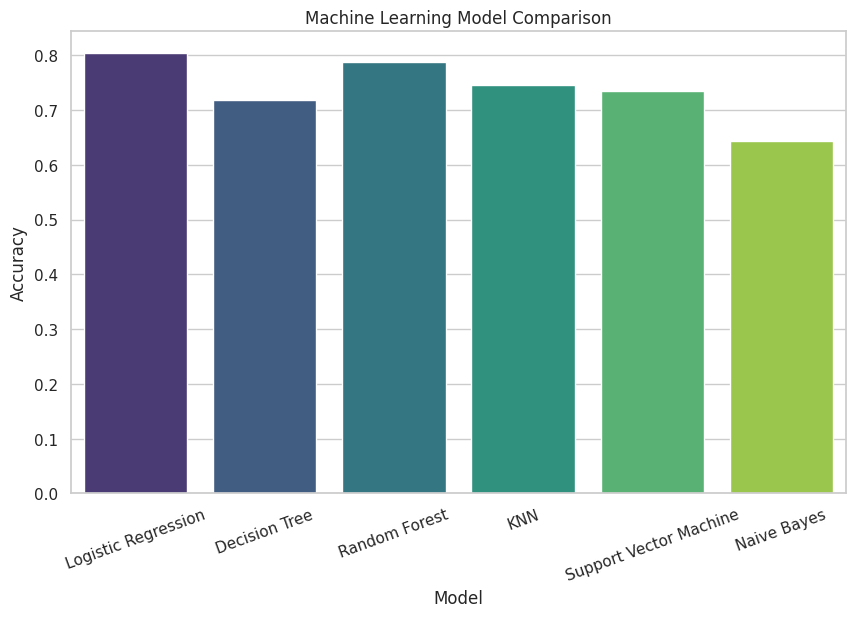

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy",
    hue="Model",
    legend=False,
    palette="viridis"
)

plt.xticks(rotation=20)

plt.title("Machine Learning Model Comparison")

plt.show()

In [46]:
best_model = results.loc[results["Accuracy"].idxmax()]

print(best_model)

Model       Logistic Regression
Accuracy               0.803127
Name: 0, dtype: object


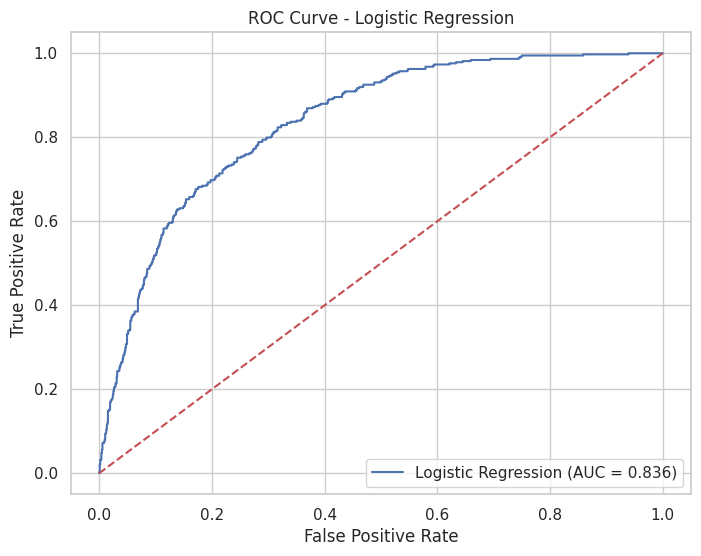

ROC-AUC Score: 0.8363897790040947


In [47]:
# Predict probabilities for the positive class
lr_prob = lr.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, lr_prob)

# Plot ROC curve
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label="Logistic Regression (AUC = {:.3f})".format(roc_auc_score(y_test, lr_prob)))
plt.plot([0,1], [0,1], 'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")

plt.show()

# Print ROC-AUC score
print("ROC-AUC Score:", roc_auc_score(y_test, lr_prob))

In [48]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(lr.coef_[0])
})

importance = importance.sort_values(by="Importance", ascending=False)

importance.head(15)

,Feature,Importance
25,Contract_Two year,1.356417
24,Contract_One year,0.748452
10,InternetService_Fiber optic,0.689165
13,OnlineSecurity_Yes,0.459153
7,PhoneService_Yes,0.426528
19,TechSupport_Yes,0.419646
28,PaymentMethod_Electronic check,0.393234
26,PaperlessBilling_Yes,0.299733
9,MultipleLines_Yes,0.280302
8,MultipleLines_No phone service,0.254493


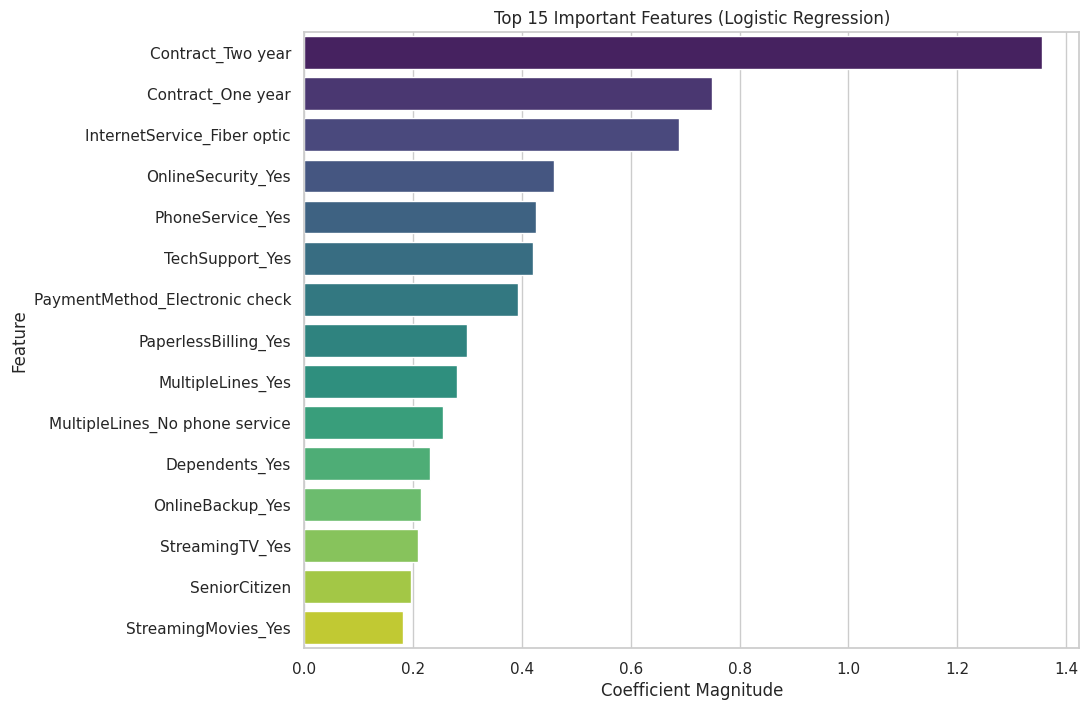

In [49]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Top 15 Important Features (Logistic Regression)")
plt.xlabel("Coefficient Magnitude")
plt.ylabel("Feature")

plt.show()

# PART 4 [Customer segmentation and bussiness insights]

In [50]:
# Create customer segments based on tenure
df["Customer_Segment"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 36, 72],
    labels=["New Customer", "Regular Customer", "Loyal Customer"]
)

# Display the count in each segment
print(df["Customer_Segment"].value_counts())

Customer_Segment
Loyal Customer      3001
New Customer        2175
Regular Customer    1856
Name: count, dtype: int64


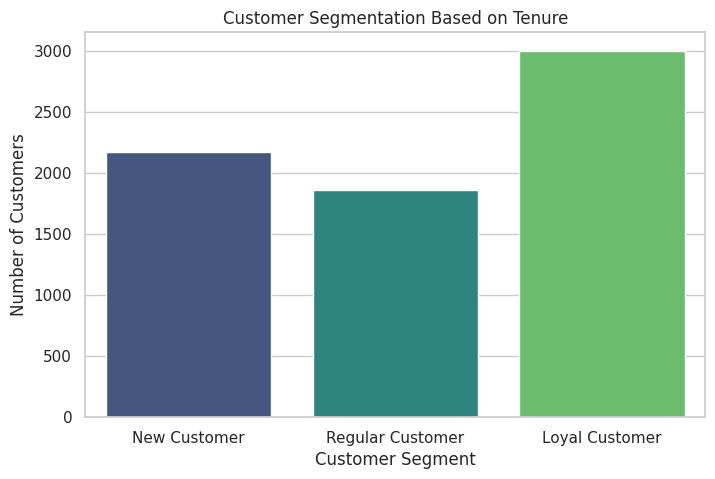

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Customer_Segment",
    hue="Customer_Segment",
    palette="viridis",
    legend=False
)

plt.title("Customer Segmentation Based on Tenure")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

In [51]:
segment_churn = pd.crosstab(
    df["Customer_Segment"],
    df["Churn"],
    normalize="index"
) * 100

print(segment_churn.round(2))

Churn                 0      1
Customer_Segment              
New Customer      52.32  47.68
Regular Customer  74.46  25.54
Loyal Customer    88.07  11.93


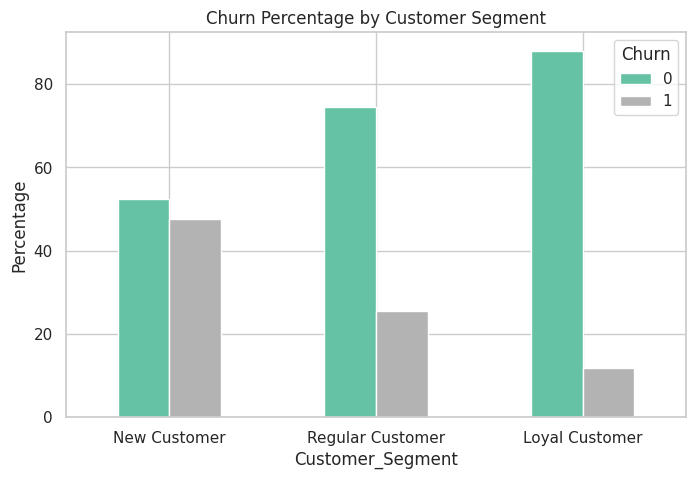

In [52]:
segment_churn.plot(
    kind="bar",
    figsize=(8,5),
    colormap="Set2"
)

plt.title("Churn Percentage by Customer Segment")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

In [53]:
high_charge = df[df["MonthlyCharges"] > df["MonthlyCharges"].median()]

print("Number of High Monthly Charge Customers:")
print(high_charge.shape[0])

Number of High Monthly Charge Customers:
3513


In [54]:
high_charge["Churn"].value_counts()

,count
Churn,
0,2276
1,1237


In [55]:
contract = pd.DataFrame()

contract["Month-to-month"] = (
    (df["Contract_One year"] == 0) &
    (df["Contract_Two year"] == 0)
)

contract["One year"] = df["Contract_One year"]

contract["Two year"] = df["Contract_Two year"]

contract.sum()

,0
Month-to-month,3875
One year,1472
Two year,1685


In [56]:
importance.head(10)

,Feature,Importance
25,Contract_Two year,1.356417
24,Contract_One year,0.748452
10,InternetService_Fiber optic,0.689165
13,OnlineSecurity_Yes,0.459153
7,PhoneService_Yes,0.426528
19,TechSupport_Yes,0.419646
28,PaymentMethod_Electronic check,0.393234
26,PaperlessBilling_Yes,0.299733
9,MultipleLines_Yes,0.280302
8,MultipleLines_No phone service,0.254493


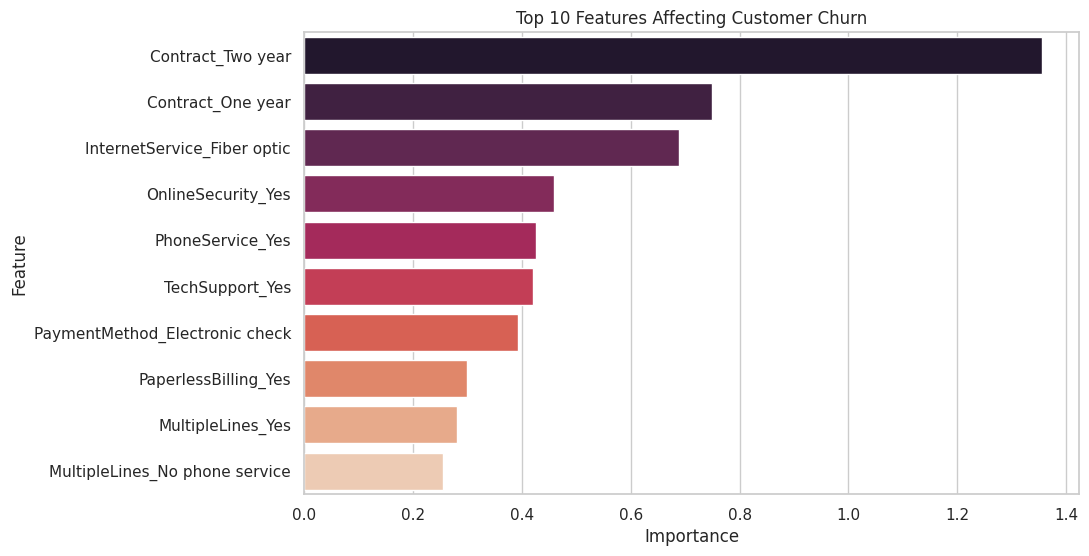

In [57]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="rocket",
    legend=False
)

plt.title("Top 10 Features Affecting Customer Churn")

plt.show()

In [ ]:
## Business Recommendations

1. Focus on retaining customers with month-to-month contracts, as they show the highest churn risk.

2. Provide loyalty rewards to long-term customers to improve retention.

3. Offer personalized discounts to customers with high monthly charges.

4. Improve customer support services for high-risk customer segments.

5. Encourage customers to switch from month-to-month plans to one-year or two-year contracts.

6. Monitor customers with short tenure, as they are more likely to churn.

7. Develop targeted marketing campaigns based on customer behavior and contract type.

In [ ]:
## Conclusion

This project successfully analyzed customer churn using exploratory data analysis and multiple machine learning models.

After comparing six classification algorithms, Logistic Regression achieved the best performance on this dataset and was selected as the final prediction model.

Business insights showed that customers with short tenure, month-to-month contracts, and higher monthly charges are more likely to churn.

The proposed recommendations can help businesses reduce customer attrition and improve customer retention strategies.

In [58]:
import joblib

# Save the trained Logistic Regression model
joblib.dump(lr, "churn_model.pkl")

# Save the feature names used during training
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Model and feature columns saved successfully!")

Model and feature columns saved successfully!
